# 🏷️ Topic Classifier — DistilBERT Fine-Tuning
### Real-Time Query Expansion & Topic Tagging — Stage 2

**Model choice:** `distilbert-base-uncased`  
> Why DistilBERT over BERT-base or RoBERTa?  
> - 40% smaller, 60% faster than BERT-base, retains 97% of its performance  
> - Our classification task (8 L1 classes, ~5k training examples) doesn't need RoBERTa's extra pre-training  
> - Ideal for deployment in a real-time inference pipeline  

**Input:** `expanded_query` (one row per user turn from the flat dataset)  
**Output:** `topic_l1` label (8 classes) + `topic_l2` label (fine-grained)  
**Two classifiers trained:** L1 (coarse) and L2 (fine) — separate heads  
**Split:** 80/20 train/test  
**Saves:** locally + push to HuggingFace Hub


## 0. Install

In [1]:
!pip install transformers datasets scikit-learn pandas torch huggingface_hub accelerate seqeval -q
print('✅ done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ done


## 1. Imports & Config

In [ ]:
import os, json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import login, HfApi

# ── CONFIG ───────────────────────────────────────────────────────
MODEL_CKPT      = "distilbert-base-uncased"
MAX_LEN         = 128
BATCH_SIZE      = 32
EPOCHS          = 8
LR              = 2e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
SEED            = 42
TEST_SIZE       = 0.2

# Paths
DATA_PATH       = Path("turns_dataset.csv")   # flat dataset (one row per turn)
L1_MODEL_DIR    = Path("models/topic_l1_classifier")
L2_MODEL_DIR    = Path("models/topic_l2_classifier")
L1_MODEL_DIR.mkdir(parents=True, exist_ok=True)
L2_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# HuggingFace Hub
HF_TOKEN        = "HF_TOKEN"   # <── replace
HF_USERNAME     = "Adignite"     # <── replace
L1_REPO_NAME    = f"{HF_USERNAME}/query-topic-l1-classifier"
L2_REPO_NAME    = f"{HF_USERNAME}/query-topic-l2-classifier"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Config ready | Device: {DEVICE}")
print(f"📦 Base model  : {MODEL_CKPT}")
print(f"📁 Data path   : {DATA_PATH}")

✅ Config ready | Device: cuda
📦 Base model  : distilbert-base-uncased
📁 Data path   : turns_dataset.csv


## 2. Load & Explore Dataset

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Total rows   : {len(df)}")
print(f"Columns      : {list(df.columns)}")
print(f"Null counts  :\n{df[['expanded_query','topic_l1','topic_l2']].isnull().sum()}")
print()

# The flat dataset has one row per user turn
# Key columns: expanded_query (text input), topic_l1, topic_l2 (labels)
# Drop rows with missing values
df = df.dropna(subset=['expanded_query', 'topic_l1', 'topic_l2'])
df['expanded_query'] = df['expanded_query'].astype(str).str.strip()
df = df[df['expanded_query'].str.len() > 2]  # remove empty/trivial queries

print(f"After cleaning: {len(df)} rows")
print()
print("── topic_l1 distribution ──")
print(df['topic_l1'].value_counts().to_string())
print()
print("── topic_l2 distribution (top 20) ──")
print(df['topic_l2'].value_counts().head(20).to_string())

Total rows   : 2046
Columns      : ['conversation_id', 'topic_l1', 'topic_l2', 'label', 'turn_index', 'user_query', 'expanded_query', 'named_entities', 'needs_expansion']
Null counts  :
expanded_query    0
topic_l1          0
topic_l2          0
dtype: int64

After cleaning: 2046 rows

── topic_l1 distribution ──
topic_l1
Politics         456
Sports           448
Technology       390
Entertainment    251
Health           211
History          103
Geography         96
General           91

── topic_l2 distribution (top 20) ──
topic_l2
India            215
AI               201
USA              176
Cricket          156
Hollywood        146
Tennis           145
Space            120
Bollywood        105
UK               101
Fitness           94
Football          93
General           91
Gadgets           69
World Wars        67
Mental Health     59
Countries         59
Nutrition         58
Olympics          54
Cities            37


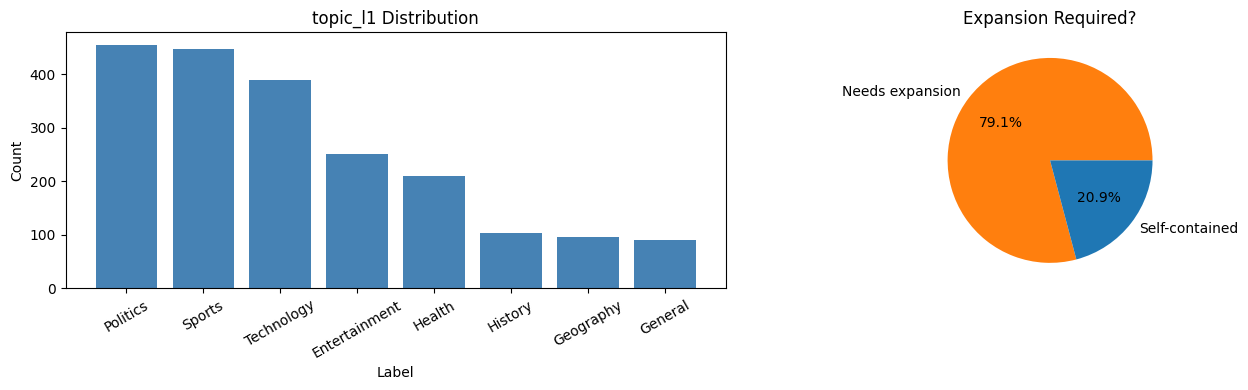

Plot saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# L1 distribution
l1_counts = df['topic_l1'].value_counts()
axes[0].bar(l1_counts.index, l1_counts.values, color='steelblue')
axes[0].set_title('topic_l1 Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# needs_expansion
if 'needs_expansion' in df.columns:
    ne_counts = df['needs_expansion'].value_counts()
    axes[1].pie(ne_counts.values, labels=['Needs expansion','Self-contained'],
                autopct='%1.1f%%', colors=['#ff7f0e','#1f77b4'])
    axes[1].set_title('Expansion Required?')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 3. Label Encoding + 80/20 Split

In [5]:
# ── ENCODE LABELS ────────────────────────────────────────────────
le_l1 = LabelEncoder()
le_l2 = LabelEncoder()

df['label_l1'] = le_l1.fit_transform(df['topic_l1'])
df['label_l2'] = le_l2.fit_transform(df['topic_l2'])

NUM_L1 = len(le_l1.classes_)
NUM_L2 = len(le_l2.classes_)

print(f"L1 classes ({NUM_L1}): {list(le_l1.classes_)}")
print(f"L2 classes ({NUM_L2}): {list(le_l2.classes_)}")

# Save label encoders
import pickle
with open(L1_MODEL_DIR / 'label_encoder.pkl', 'wb') as f: pickle.dump(le_l1, f)
with open(L2_MODEL_DIR / 'label_encoder.pkl', 'wb') as f: pickle.dump(le_l2, f)

# Also save as JSON for easy loading without pickle
json.dump({"id2label": dict(enumerate(le_l1.classes_.tolist())),
           "label2id": {v:k for k,v in enumerate(le_l1.classes_.tolist())}},
          open(L1_MODEL_DIR / 'label_map.json','w'), indent=2)
json.dump({"id2label": dict(enumerate(le_l2.classes_.tolist())),
           "label2id": {v:k for k,v in enumerate(le_l2.classes_.tolist())}},
          open(L2_MODEL_DIR / 'label_map.json','w'), indent=2)

print("\n✅ Label encoders saved.")

L1 classes (8): ['Entertainment', 'General', 'Geography', 'Health', 'History', 'Politics', 'Sports', 'Technology']
L2 classes (19): ['AI', 'Bollywood', 'Cities', 'Countries', 'Cricket', 'Fitness', 'Football', 'Gadgets', 'General', 'Hollywood', 'India', 'Mental Health', 'Nutrition', 'Olympics', 'Space', 'Tennis', 'UK', 'USA', 'World Wars']

✅ Label encoders saved.


In [6]:
# ── 80/20 STRATIFIED SPLIT ───────────────────────────────────────
train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=SEED, stratify=df['label_l1']
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):>5} rows")
print(f"Test  : {len(test_df):>5} rows")
print()
print("Train L1 distribution:")
print(train_df['topic_l1'].value_counts().to_string())

Train :  1636 rows
Test  :   410 rows

Train L1 distribution:
topic_l1
Politics         364
Sports           358
Technology       312
Entertainment    201
Health           169
History           82
Geography         77
General           73


## 4. Dataset Class + Tokeniser

In [7]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_CKPT)

class TopicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx],
        }

print("✅ Tokenizer and Dataset class ready.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer and Dataset class ready.


## 5. Metrics + Training Utilities

In [10]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
    }

def get_training_args(output_dir, epochs=EPOCHS):
    return TrainingArguments(
        output_dir                  = str(output_dir),
        num_train_epochs            = epochs,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE,
        learning_rate               = LR,
        weight_decay                = WEIGHT_DECAY,
        warmup_ratio                = WARMUP_RATIO,
        eval_strategy               = 'epoch',       # <--- FIXED HERE
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1_weighted',
        greater_is_better           = True,
        logging_dir                 = str(output_dir / 'logs'),
        logging_steps               = 50,
        save_total_limit            = 2,
        seed                        = SEED,
        report_to                   = 'none',
        fp16                        = torch.cuda.is_available(),
    )

print("✅ Metrics and training args ready.")

✅ Metrics and training args ready.


## 6. Train L1 Classifier (Coarse Topics)
`Politics | Sports | Technology | Entertainment | Health | History | Geography | General`

In [11]:
print("=" * 55)
print("  Training L1 Topic Classifier")
print("=" * 55)

# Build datasets
train_ds_l1 = TopicDataset(train_df['expanded_query'], train_df['label_l1'], tokenizer)
test_ds_l1  = TopicDataset(test_df['expanded_query'],  test_df['label_l1'],  tokenizer)

# Build id2label / label2id for the model config
id2label_l1 = {i: c for i, c in enumerate(le_l1.classes_)}
label2id_l1 = {c: i for i, c in id2label_l1.items()}

# Load model
model_l1 = DistilBertForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels  = NUM_L1,
    id2label    = id2label_l1,
    label2id    = label2id_l1,
)

trainer_l1 = Trainer(
    model           = model_l1,
    args            = get_training_args(L1_MODEL_DIR),
    train_dataset   = train_ds_l1,
    eval_dataset    = test_ds_l1,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print(f"Training on {len(train_ds_l1)} samples | Eval on {len(test_ds_l1)} samples")
trainer_l1.train()
print("\n✅ L1 training complete.")

  Training L1 Topic Classifier


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training on 1636 samples | Eval on 410 samples


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.876270,1.307346,0.753659,0.500199,0.689828
2,0.826174,0.358709,0.958537,0.940694,0.959732
3,0.312105,0.209626,0.951220,0.942336,0.951092
4,0.190405,0.183978,0.948780,0.937639,0.948731
5,0.146063,0.157429,0.956098,0.946712,0.955975


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ L1 training complete.


## 7. Train L2 Classifier (Fine-grained Topics)

In [12]:
print("=" * 55)
print("  Training L2 Topic Classifier")
print("=" * 55)

train_ds_l2 = TopicDataset(train_df['expanded_query'], train_df['label_l2'], tokenizer)
test_ds_l2  = TopicDataset(test_df['expanded_query'],  test_df['label_l2'],  tokenizer)

id2label_l2 = {i: c for i, c in enumerate(le_l2.classes_)}
label2id_l2 = {c: i for i, c in id2label_l2.items()}

model_l2 = DistilBertForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels  = NUM_L2,
    id2label    = id2label_l2,
    label2id    = label2id_l2,
)

trainer_l2 = Trainer(
    model           = model_l2,
    args            = get_training_args(L2_MODEL_DIR),
    train_dataset   = train_ds_l2,
    eval_dataset    = test_ds_l2,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print(f"Training on {len(train_ds_l2)} samples | Eval on {len(test_ds_l2)} samples")
trainer_l2.train()
print("\n✅ L2 training complete.")

  Training L2 Topic Classifier


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training on 1636 samples | Eval on 410 samples


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,2.857942,2.461895,0.482927,0.282294,0.388793
2,1.970309,1.255430,0.900000,0.887287,0.896977
3,1.091500,0.691576,0.943902,0.942523,0.944895
4,0.684011,0.482578,0.936585,0.938241,0.936926
5,0.477424,0.373120,0.948780,0.947555,0.949533
6,0.374278,0.332915,0.946341,0.944549,0.946647
7,0.322756,0.316614,0.943902,0.942410,0.944249
8,0.279657,0.310493,0.943902,0.942410,0.944249


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ L2 training complete.


## 8. Evaluate Both Models


  Evaluation: L1 Topic


  Loss         : 0.3587
  Accuracy     : 95.85%
  F1 Macro     : 94.07%
  F1 Weighted  : 95.97%

               precision    recall  f1-score   support

Entertainment       1.00      0.96      0.98        50
      General       0.68      0.94      0.79        18
    Geography       1.00      0.84      0.91        19
       Health       0.98      1.00      0.99        42
      History       1.00      0.90      0.95        21
     Politics       0.97      0.93      0.95        92
       Sports       0.98      0.98      0.98        90
   Technology       0.96      0.99      0.97        78

     accuracy                           0.96       410
    macro avg       0.95      0.94      0.94       410
 weighted avg       0.96      0.96      0.96       410



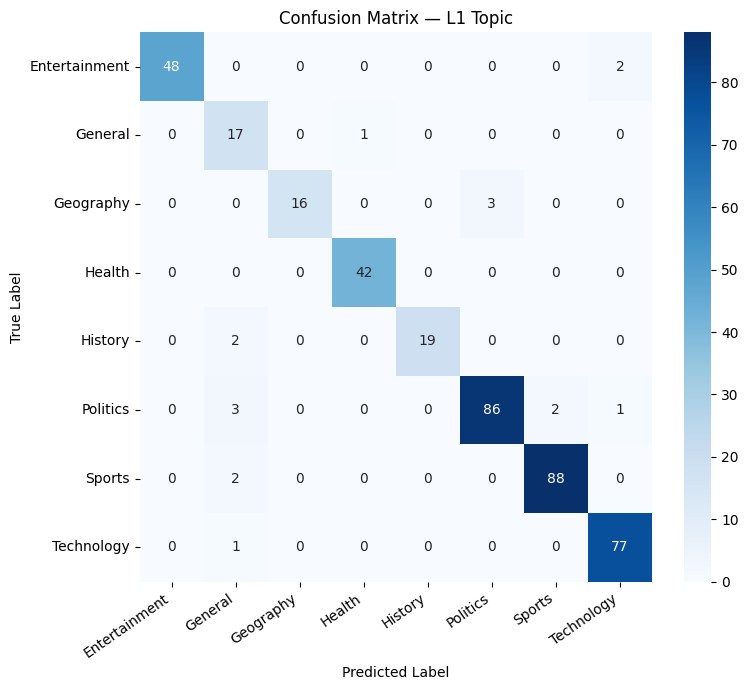


  Evaluation: L2 Topic


  Loss         : 0.3731
  Accuracy     : 94.88%
  F1 Macro     : 94.76%
  F1 Weighted  : 94.95%

               precision    recall  f1-score   support

           AI       0.93      1.00      0.97        42
    Bollywood       1.00      0.96      0.98        23
       Cities       1.00      1.00      1.00         5
    Countries       0.92      0.86      0.89        14
      Cricket       0.82      1.00      0.90        23
      Fitness       0.95      1.00      0.97        19
     Football       1.00      1.00      1.00        19
      Gadgets       1.00      0.90      0.95        10
      General       0.74      0.94      0.83        18
    Hollywood       1.00      0.96      0.98        27
        India       0.93      0.98      0.95        41
Mental Health       1.00      1.00      1.00        11
    Nutrition       1.00      0.92      0.96        12
     Olympics       1.00      0.80      0.89        10
        Space       1.00      0.96      0.98        26
       Tennis       1.

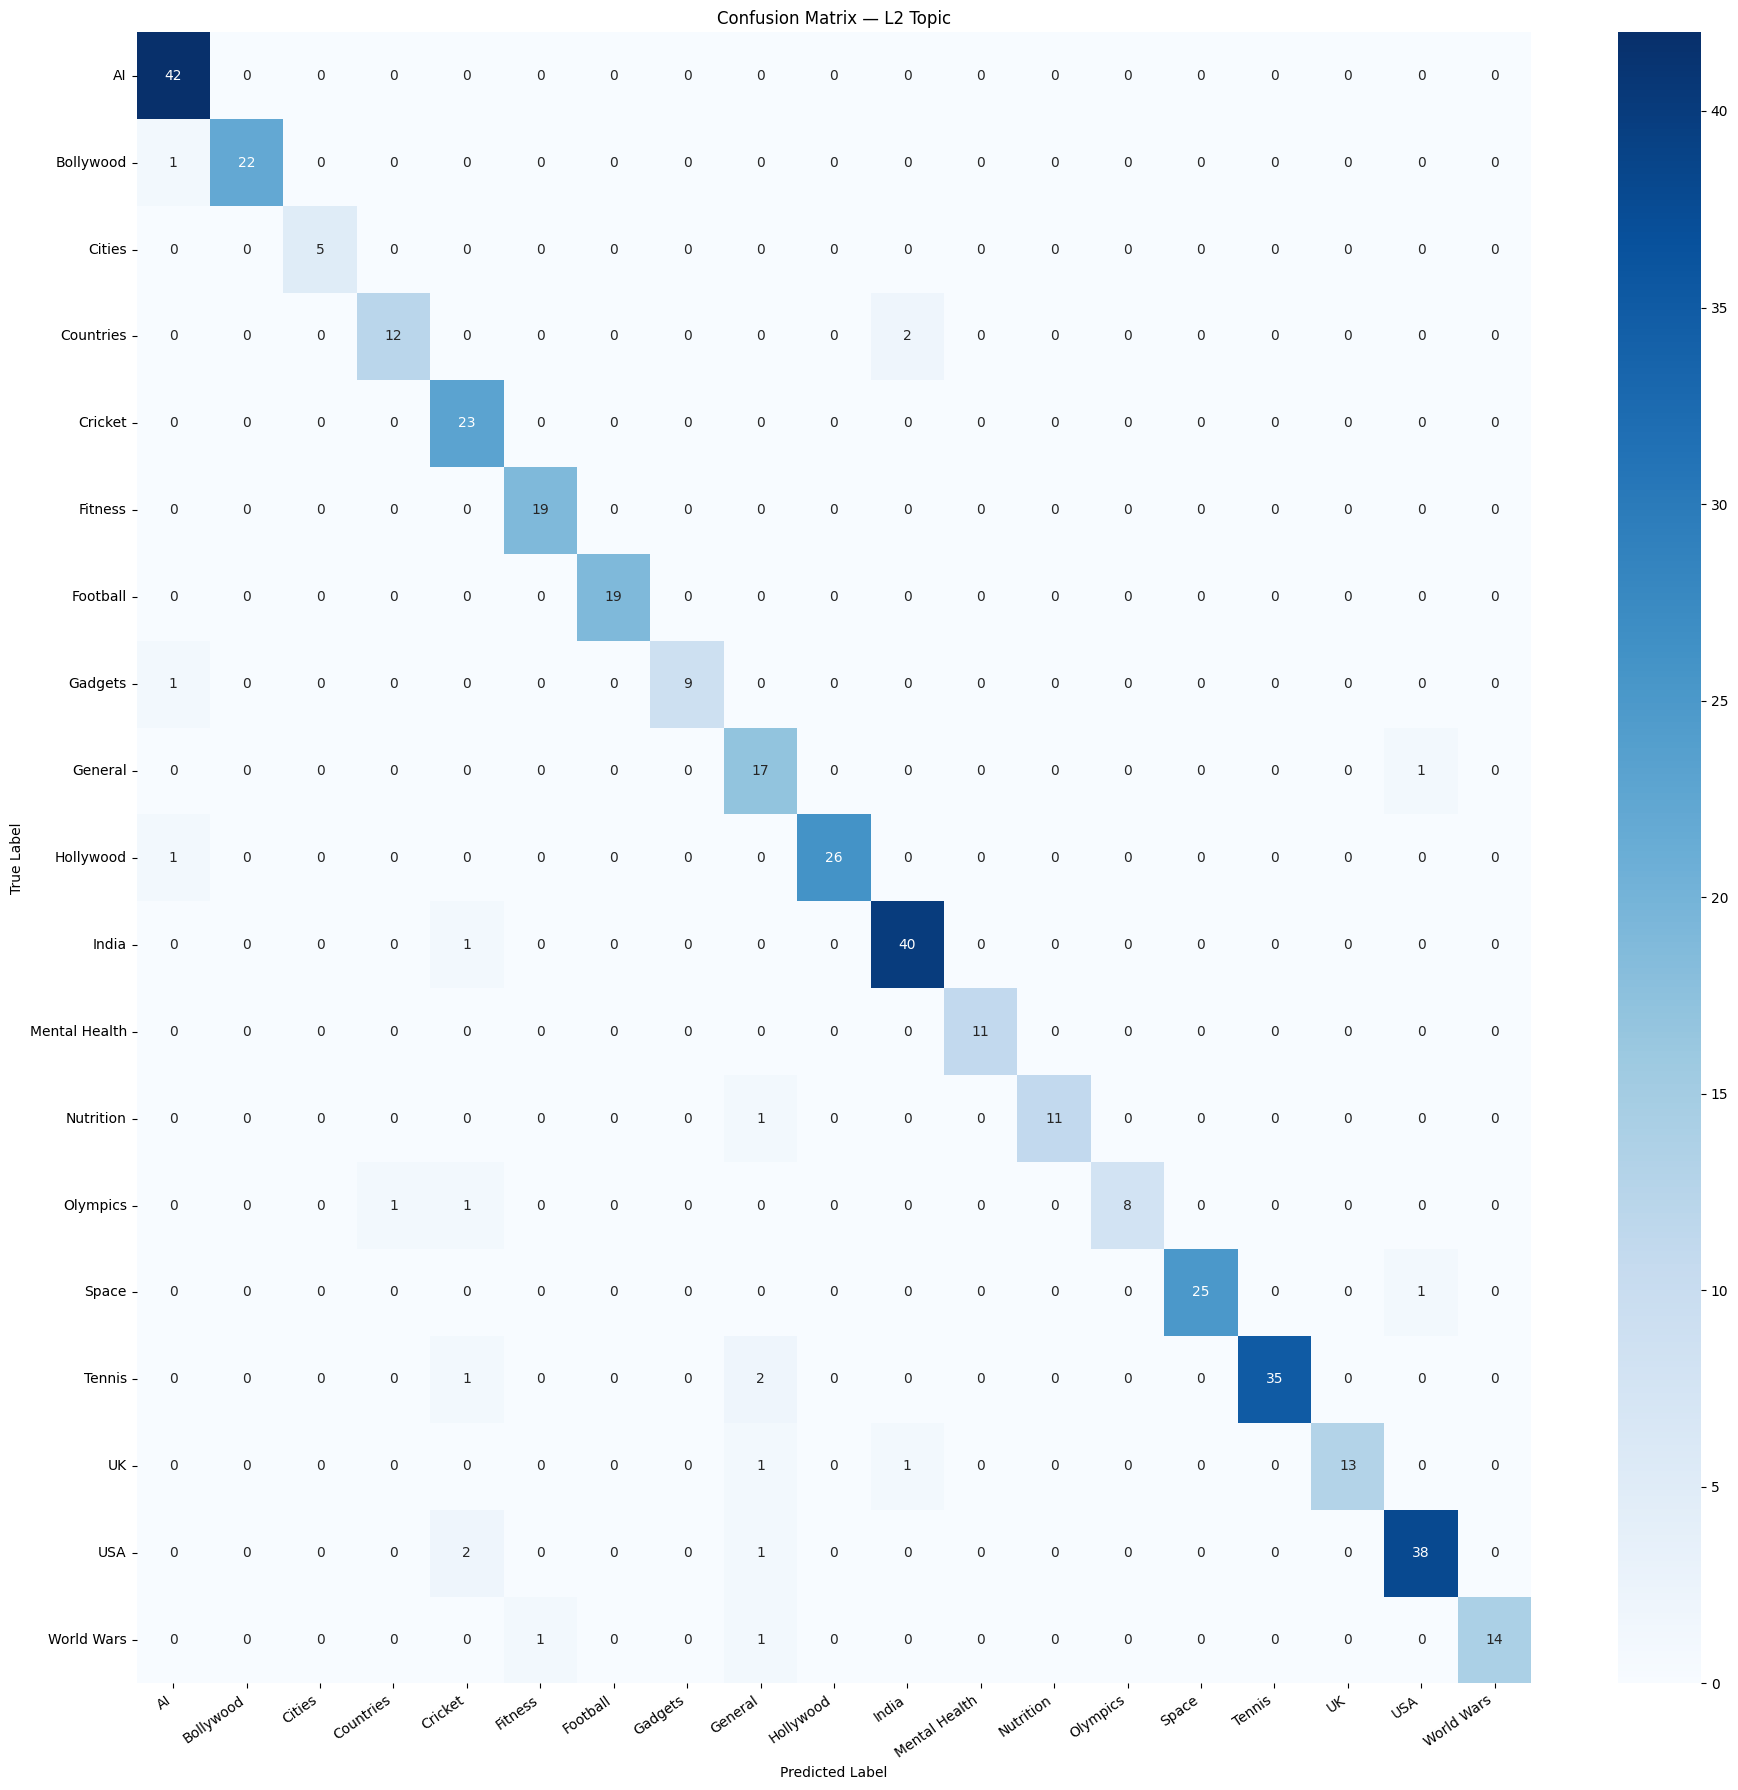

In [13]:
def full_evaluation(trainer, dataset, label_encoder, level_name):
    print(f"\n{'='*55}")
    print(f"  Evaluation: {level_name}")
    print(f"{'='*55}")

    # Trainer evaluation (loss + metrics)
    results = trainer.evaluate(dataset)
    print(f"  Loss         : {results['eval_loss']:.4f}")
    print(f"  Accuracy     : {results['eval_accuracy']*100:.2f}%")
    print(f"  F1 Macro     : {results['eval_f1_macro']*100:.2f}%")
    print(f"  F1 Weighted  : {results['eval_f1_weighted']*100:.2f}%")

    # Per-class classification report
    preds_out = trainer.predict(dataset)
    preds     = np.argmax(preds_out.predictions, axis=-1)
    labels    = preds_out.label_ids
    class_names = label_encoder.classes_

    print(f"\n{classification_report(labels, preds, target_names=class_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(max(8, len(class_names)), max(6, len(class_names)-1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {level_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(f'confusion_{level_name.lower().replace(" ","_")}.png', dpi=150)
    plt.show()

    return results


results_l1 = full_evaluation(trainer_l1, test_ds_l1, le_l1, "L1 Topic")
results_l2 = full_evaluation(trainer_l2, test_ds_l2, le_l2, "L2 Topic")

## 9. Save Models Locally

In [14]:
# Save best model + tokenizer
trainer_l1.save_model(str(L1_MODEL_DIR / 'best_model'))
tokenizer.save_pretrained(str(L1_MODEL_DIR / 'best_model'))

trainer_l2.save_model(str(L2_MODEL_DIR / 'best_model'))
tokenizer.save_pretrained(str(L2_MODEL_DIR / 'best_model'))

print(f"✅ L1 model saved → {L1_MODEL_DIR / 'best_model'}")
print(f"✅ L2 model saved → {L2_MODEL_DIR / 'best_model'}")
print(f"\nFiles saved:")
for p in (L1_MODEL_DIR / 'best_model').iterdir():
    print(f"   {p.name}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ L1 model saved → models/topic_l1_classifier/best_model
✅ L2 model saved → models/topic_l2_classifier/best_model

Files saved:
   model.safetensors
   tokenizer.json
   config.json
   training_args.bin
   tokenizer_config.json


## 10. Push to HuggingFace Hub

In [15]:
login(token=HF_TOKEN)

def push_to_hub(model_dir, repo_name, level_name, results):
    print(f"\nPushing {level_name} → {repo_name}")

    # Load best model for pushing
    model = DistilBertForSequenceClassification.from_pretrained(str(model_dir / 'best_model'))
    tok   = DistilBertTokenizerFast.from_pretrained(str(model_dir / 'best_model'))

    # Write model card
    readme = f"""---
language: en
tags:
  - text-classification
  - topic-classification
  - query-expansion
  - conversational-ai
---

# {level_name} Topic Classifier

Fine-tuned `distilbert-base-uncased` for {level_name} topic classification in multi-turn dialogue.

## Usage
```python
from transformers import pipeline
classifier = pipeline("text-classification", model="{repo_name}")
result = classifier("who is the prime minister of india?")
print(result)  # [{{'label': 'Politics', 'score': 0.97}}]
```

## Metrics (test set)
- Accuracy : {results.get('eval_accuracy', 0)*100:.2f}%
- F1 Macro : {results.get('eval_f1_macro', 0)*100:.2f}%
- F1 Weighted : {results.get('eval_f1_weighted', 0)*100:.2f}%
"""
    (model_dir / 'best_model' / 'README.md').write_text(readme)

    model.push_to_hub(repo_name, token=HF_TOKEN)
    tok.push_to_hub(repo_name, token=HF_TOKEN)
    print(f"   ✅ Pushed → https://huggingface.co/{repo_name}")


push_to_hub(L1_MODEL_DIR, L1_REPO_NAME, "L1", results_l1)
push_to_hub(L2_MODEL_DIR, L2_REPO_NAME, "L2", results_l2)


Pushing L1 → Adignite/query-topic-l1-classifier


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...xiivubk/model.safetensors:   1%|1         | 4.01MB /  268MB            

README.md: 0.00B [00:00, ?B/s]

   ✅ Pushed → https://huggingface.co/Adignite/query-topic-l2-classifier


## 11. Quick Inference Test

In [17]:
from transformers import pipeline as hf_pipeline

# Load from local save
clf_l1 = hf_pipeline('text-classification',
                      model=str(L1_MODEL_DIR / 'best_model'),
                      tokenizer=str(L1_MODEL_DIR / 'best_model'),
                      device=0 if torch.cuda.is_available() else -1)

clf_l2 = hf_pipeline('text-classification',
                      model=str(L2_MODEL_DIR / 'best_model'),
                      tokenizer=str(L2_MODEL_DIR / 'best_model'),
                      device=0 if torch.cuda.is_available() else -1)

test_queries = [
    "who is the prime minister of india?",
    "what are Virat Kohli's achievements in test cricket?",
    "how does OpenAI's GPT model work?",
    "what are the health benefits of yoga?",
    "brb",
    "compare Narendra Modi and Rahul Gandhi's policies",
    "who won the FIFA World Cup 2022?",
    "what is the capital of France?",
]

print(f"{'Query':<55} {'L1':^18} {'L2':^20}")
print("-" * 95)
for q in test_queries:
    r1 = clf_l1(q)[0]
    r2 = clf_l2(q)[0]
    l1 = f"{r1['label']} ({r1['score']:.2f})"
    l2 = f"{r2['label']} ({r2['score']:.2f})"
    print(f"{q[:53]:<55} {l1:^18} {l2:^20}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Query                                                           L1                  L2         
-----------------------------------------------------------------------------------------------
who is the prime minister of india?                      Politics (0.85)       India (0.85)    
what are Virat Kohli's achievements in test cricket?      Sports (0.93)       Cricket (0.90)   
how does OpenAI's GPT model work?                       Technology (0.87)       AI (0.93)      
what are the health benefits of yoga?                     Health (0.81)       Fitness (0.80)   
brb                                                     Technology (0.24)     Cricket (0.34)   
compare Narendra Modi and Rahul Gandhi's policies        Politics (0.90)       India (0.93)    
who won the FIFA World Cup 2022?                          Sports (0.82)      Football (0.67)   
what is the capital of France?                           Geography (0.33)     Cities (0.49)    


## 12. Summary

In [18]:
print("\n" + "="*55)
print("  TRAINING SUMMARY")
print("="*55)
print(f"  Base model       : {MODEL_CKPT}")
print(f"  Train samples    : {len(train_df)}")
print(f"  Test  samples    : {len(test_df)}")
print()
print(f"  L1 Classifier ({NUM_L1} classes)")
print(f"     Accuracy     : {results_l1.get('eval_accuracy',0)*100:.2f}%")
print(f"     F1 Weighted  : {results_l1.get('eval_f1_weighted',0)*100:.2f}%")
print(f"     Saved locally: {L1_MODEL_DIR / 'best_model'}")
print(f"     HF Hub       : https://huggingface.co/{L1_REPO_NAME}")
print()
print(f"  L2 Classifier ({NUM_L2} classes)")
print(f"     Accuracy     : {results_l2.get('eval_accuracy',0)*100:.2f}%")
print(f"     F1 Weighted  : {results_l2.get('eval_f1_weighted',0)*100:.2f}%")
print(f"     Saved locally: {L2_MODEL_DIR / 'best_model'}")
print(f"     HF Hub       : https://huggingface.co/{L2_REPO_NAME}")


  TRAINING SUMMARY
  Base model       : distilbert-base-uncased
  Train samples    : 1636
  Test  samples    : 410

  L1 Classifier (8 classes)
     Accuracy     : 95.85%
     F1 Weighted  : 95.97%
     Saved locally: models/topic_l1_classifier/best_model
     HF Hub       : https://huggingface.co/Adignite/query-topic-l1-classifier

  L2 Classifier (19 classes)
     Accuracy     : 94.88%
     F1 Weighted  : 94.95%
     Saved locally: models/topic_l2_classifier/best_model
     HF Hub       : https://huggingface.co/Adignite/query-topic-l2-classifier
